# Information Visualisation Assignment 2

## Dublin tree dataset from UCD School of Geography
Ningal, T., & Mills, G. (2020). Dublin Trees GIS Database (Version 001) [Data set]. Zenodo.
https://doi.org/10.5281/zenodo.3813792

In [94]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

In [95]:
# Load the shapefile
trees = gpd.read_file('data/dublin-trees/ESRI_Shape/Dublin_Trees_V001_2020_05_05_Ningal_Mills.shp')

print(trees.shape)
print(trees.columns.tolist())
print(trees.crs)

(303981, 21)
['FID_', 'Curio_ID', 'Species_Co', 'Species_La', 'Diameter', 'Tree_Heigh', 'Tree_DEM', 'Vitality', 'Contributo', 'Contribu_1', 'Date_Rec', 'Recorder', 'Last_Updat', 'Updated_By', 'MGRS', 'What3words', 'POINT_Y', 'POINT_X', 'StreetTree', 'Public', 'geometry']
EPSG:4326


In [96]:
trees.head()

,FID_,Curio_ID,Species_Co,Species_La,Diameter,Tree_Heigh,Tree_DEM,Vitality,Contributo,Contribu_1,...,Recorder,Last_Updat,Updated_By,MGRS,What3words,POINT_Y,POINT_X,StreetTree,Public,geometry
0,42749,2216384,None,None,0.0,0.0,3.9,Good,Tine Ningal/Gerald Mills/Michael Brennan,UCD School of Geography,...,None,None,None,29UPV8323612407,None,53.329058,-6.248367,0,0,POINT (-6.24837 53.32906)
1,42750,2216384,None,None,0.0,0.0,7.0,Good,Tine Ningal/Gerald Mills/Michael Brennan,UCD School of Geography,...,None,None,None,29UPV8322412410,None,53.329090,-6.248544,0,0,POINT (-6.24854 53.32909)
2,42751,2216384,None,None,0.0,0.0,7.1,Good,Tine Ningal/Gerald Mills/Michael Brennan,UCD School of Geography,...,None,None,None,29UPV8322812417,None,53.329152,-6.248481,0,0,POINT (-6.24848 53.32915)
3,42752,2216384,None,None,0.0,0.0,5.9,Good,Tine Ningal/Gerald Mills/Michael Brennan,UCD School of Geography,...,None,None,None,29UPV8323012420,None,53.329182,-6.248444,0,0,POINT (-6.24844 53.32918)
4,42753,2216384,None,None,0.0,0.0,15.0,Good,Tine Ningal/Gerald Mills/Michael Brennan,UCD School of Geography,...,None,None,None,29UPV8322812454,None,53.329488,-6.248462,0,0,POINT (-6.24846 53.32949)


In [97]:
trees.describe()

,FID_,Curio_ID,Diameter,Tree_Heigh,Tree_DEM,Date_Rec,POINT_Y,POINT_X,StreetTree,Public
count,303981.000000,3.039810e+05,303981.000000,303981.000000,303981.000000,2440,303981.000000,303981.000000,303981.000000,303981.000000
mean,151990.000000,1.699433e+06,13.071545,0.069731,7.788238,1956-09-30 11:18:41.312000,53.358231,-6.262712,0.008027,0.007691
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1872-08-14 00:00:00,53.298972,-6.387205,0.000000,0.000000
25%,75995.000000,0.000000e+00,0.000000,0.000000,4.300000,1899-12-29 00:00:00,53.332830,-6.303707,0.000000,0.000000
50%,151990.000000,2.414479e+06,0.000000,0.000000,6.900000,2008-11-15 00:00:00,53.362422,-6.262705,0.000000,0.000000
75%,227985.000000,2.496349e+06,0.000000,0.000000,10.800000,2009-02-17 00:00:00,53.380736,-6.223150,0.000000,0.000000
max,303980.000000,2.577360e+06,2500.000000,19.500000,42.700000,2009-02-20 00:00:00,53.410981,-6.118089,1.000000,1.000000
std,87751.900427,1.120372e+06,137.634546,0.838785,5.413919,NaN,0.027979,0.052129,0.089232,0.087362


In [102]:
print(trees[['Species_Co', 'Tree_Heigh', 'Vitality', 'Tree_DEM', 'StreetTree']].notna().sum())
print("Non-zero Tree_Heigh:", (trees['Tree_Heigh'] > 0).sum())
print("Non-zero Diameter:", (trees['Diameter'] > 0).sum())
print("StreetTree == 1:", (trees['StreetTree'] == 1).sum())
print(trees['Vitality'].value_counts())

Species_Co    159287
Tree_Heigh    303981
Vitality      238599
Tree_DEM      303981
StreetTree    303981
dtype: int64
Non-zero Tree_Heigh: 2440
Non-zero Diameter: 26070
StreetTree == 1: 2440
Vitality
Good         237564
Poor            551
Moderate        475
Very poor         9
Name: count, dtype: int64


In [99]:
# Species distribution
print(trees['Species_Co'].value_counts().head(20))

Species_Co
english oak                  20981
cork oak                     10875
alder                        10587
willow                        9796
arbutus unedo x andrachne     8146
sycamore                      7458
elder                         7438
hawthorn                      7254
holm oak                      5400
monkey puzzle                 4991
horse chestnut                4878
hasselsläktet                 4568
crabapple                     3688
london plane                  3491
lime                          3030
hinoki cypress                2854
irish yew                     2309
hornbeam                      2231
aspen                         2228
western red cedar             2186
Name: count, dtype: int64


In [103]:
# Height distribution
print(trees['Tree_DEM'].describe())

count    303981.000000
mean          7.788238
std           5.413919
min           0.000000
25%           4.300000
50%           6.900000
75%          10.800000
max          42.700000
Name: Tree_DEM, dtype: float64


In [104]:
trees['Vitality_Simple'] = trees['Vitality'].apply(
    lambda x: 'Good' if x == 'Good' else ('Poor' if x in ['Poor', 'Moderate', 'Very poor'] else None)
)

print(trees['Vitality_Simple'].value_counts())

Vitality_Simple
Good    237564
Poor      1035
Name: count, dtype: int64


## Property Price Register

In [105]:
# PPR for Dublin only
ppr = pd.read_csv('data/ppr-all.csv', encoding='windows-1252', low_memory=False)
ppr.columns = ppr.columns.str.strip()

ppr = ppr[ppr['County'] == 'Dublin'].copy()

# Parse date and extract year
ppr['Date'] = pd.to_datetime(ppr['Date of Sale (dd/mm/yyyy)'], dayfirst=True)
ppr['Year'] = ppr['Date'].dt.year

# Clean price
ppr['Price'] = ppr['Price (€)'].str.replace('€', '').str.replace(',', '').astype(float)

# Full market price only
ppr = ppr[ppr['Not Full Market Price'] == 'No'].copy()

# Keep relevant columns
ppr = ppr[['Date', 'Year', 'Price', 'Address', 'Eircode', 'Description of Property']].copy()

In [106]:
ppr.head()

,Date,Year,Price,Address,Eircode,Description of Property
0,2010-01-01,2010,343000.0,"5 Braemor Drive, Churchtown, Co.Dublin",NaN,Second-Hand Dwelling house /Apartment
2,2010-01-04,2010,438500.0,"1 Meadow Avenue, Dundrum, Dublin 14",NaN,Second-Hand Dwelling house /Apartment
5,2010-01-04,2010,425000.0,"12 Sallymount Avenue, Ranelagh",NaN,Second-Hand Dwelling house /Apartment
11,2010-01-04,2010,430000.0,"206 Philipsburgh Avenue, Marino, Dublin 3",NaN,Second-Hand Dwelling house /Apartment
12,2010-01-04,2010,355000.0,"22 Laverna Way, Castleknock, Dublin 15",NaN,Second-Hand Dwelling house /Apartment


In [107]:
ppr = ppr[ppr['Year'] >= 2016].copy()

In [108]:
ppr.head()

,Date,Year,Price,Address,Eircode,Description of Property
187883,2016-01-01,2016,170000.0,"34 MOUNT PLEASANT TERRACE, RANELAGH, DUBLIN 6",NaN,Second-Hand Dwelling house /Apartment
187888,2016-01-04,2016,230088.0,"13 Drury Mills, Saggart",NaN,New Dwelling house /Apartment
187896,2016-01-04,2016,321586.0,"19 Drury Mills, Saggart",NaN,New Dwelling house /Apartment
187897,2016-01-04,2016,1150000.0,"2 BRIGHTON SQ, BRIGHTON RD, FOXROCK DUBLIN 18",NaN,Second-Hand Dwelling house /Apartment
187899,2016-01-04,2016,330000.0,"2 MOYOLA MEWS, LOWER CHURCHTOWN ROAD, DUBLIN 14",NaN,Second-Hand Dwelling house /Apartment


In [109]:
ppr.shape

(174487, 6)

In [110]:
def get_geocode_input(row):
    eircode = str(row['Eircode']).strip()
    if eircode and eircode != 'nan':
        return eircode + ', Ireland'
    else:
        return str(row['Address']).strip() + ', Dublin, Ireland'

ppr['geocode_input'] = ppr.apply(get_geocode_input, axis=1)

# Check the split
eircode_count = ppr['Eircode'].notna().sum()
address_count = ppr['Eircode'].isna().sum()
print(f"With Eircode: {eircode_count}")
print(f"Using Address: {address_count}")

With Eircode: 72827
Using Address: 101660


# Found a dataset with the co-ords

In [ ]:
import glob

path = 'data/geocoded-ppr/data/csv/years/*.csv'
files = glob.glob(path)

dfs = []
for f in files:
    df = pd.read_csv(f, low_memory=False)
    dfs.append(df)

ppr_geo = pd.concat(dfs, ignore_index=True)

print(ppr_geo.shape)
print(ppr_geo.columns.tolist())
print(ppr_geo.head())

In [ ]:
# Check coordinate coverage
print("Rows with coordinates:", ppr_geo[['latitude', 'longitude']].notna().all(axis=1).sum())
print("Rows missing coordinates:", ppr_geo[['latitude', 'longitude']].isna().any(axis=1).sum())

# Check year range
print(ppr_geo['year_of_sale'].value_counts().sort_index())

In [ ]:
print(ppr_geo['County'].value_counts().head(10))

In [ ]:
ppr_geo[ppr_geo['County'] == 'Dublin'].describe()

In [ ]:
ppr_geo = ppr_geo[
    (ppr_geo['latitude'] >= 53.2350) & (ppr_geo['latitude'] <= 53.3565) &
    (ppr_geo['longitude'] >= -6.5359) & (ppr_geo['longitude'] <= -6.0293)
].copy()

print(f"Rows remaining: {len(ppr_geo)}")
print(ppr_geo[['latitude', 'longitude']].describe())

In [ ]:
print(ppr_geo['year_of_sale'].value_counts().sort_index())

# Using the geo data 2016-2020 then getting 2021-2026 co-ords myself

In [ ]:
ppr_to_geocode = ppr[
    (ppr['Year'] >= 2021)
].copy()

print(f"Rows to geocode: {len(ppr_to_geocode)}")
ppr_final = ppr_geo[
    (ppr_geo['year_of_sale'] >= 2016) &
    (ppr_geo['year_of_sale'] <= 2020)
].copy()

print(ppr_final['year_of_sale'].value_counts().sort_index())
print(f"Total rows: {len(ppr_final)}")

In [ ]:
ppr_to_geocode = ppr[ppr['Year'] >= 2021].copy()

print(f"Rows to geocode: {len(ppr_to_geocode)}")

In [ ]:
ppr_test = ppr_geo.sample(1000, random_state=42).copy()
print(ppr_test.shape)

In [ ]:
ppr_test.head()

In [ ]:
import requests
from urllib.parse import quote

API_KEY = input("Enter your Google Maps API key:")

def geocode_address(address):
    # URL encode the address
    encoded = quote(address + ', Dublin, Ireland')
    url = f'https://geocode.googleapis.com/v4/geocode/address/{encoded}'

    params = {
        'key': API_KEY,
        'regionCode': 'IE',
        # Bias to Dublin bounding box
        'locationBias.rectangle.low.latitude': 53.2350,
        'locationBias.rectangle.low.longitude': -6.5359,
        'locationBias.rectangle.high.latitude': 53.3565,
        'locationBias.rectangle.high.longitude': -6.0293
    }

    response = requests.get(url, params=params)
    data = response.json()

    if 'results' in data and len(data['results']) > 0:
        lat = data['results'][0]['location']['latitude']
        lng = data['results'][0]['location']['longitude']
        return lat, lng, 'ok'
    return None, None, str(data)

# # Test
# lat, lng, status = geocode_address('12 Sallymount Avenue, Ranelagh')
# print(lat, lng, status)

# fixing mistake...

In [ ]:
import pandas as pd

# Load partial geocoded file
geocoded_partial = pd.read_csv('data/geocoded_2021_2026.csv', low_memory=False)
print(f"Partial geocoded: {len(geocoded_partial)}")
print(f"Already geocoded: {geocoded_partial['latitude'].notna().sum()}")

# Get full 2021+ Dublin rows from already loaded ppr
ppr_full = ppr[ppr['Year'] >= 2021].copy().reset_index(drop=True)
ppr_full['latitude'] = None
ppr_full['longitude'] = None
ppr_full['geocode_status'] = None

print(f"Full dataset: {len(ppr_full)}")

# Merge on Address to carry over existing coordinates
merged = ppr_full.merge(
    geocoded_partial[['Address', 'latitude', 'longitude', 'geocode_status']].drop_duplicates('Address'),
    on='Address',
    how='left',
    suffixes=('', '_geocoded')
)

# Use geocoded values where available
merged['latitude'] = merged['latitude_geocoded'].combine_first(merged['latitude'])
merged['longitude'] = merged['longitude_geocoded'].combine_first(merged['longitude'])
merged['geocode_status'] = merged['geocode_status_geocoded'].combine_first(merged['geocode_status'])

# Drop helper columns
merged = merged.drop(columns=['latitude_geocoded', 'longitude_geocoded', 'geocode_status_geocoded'])

merged = merged.reset_index(drop=True)

print(f"Merged total: {len(merged)}")
print(f"Already geocoded: {merged['latitude'].notna().sum()}")
print(f"Remaining: {merged['latitude'].isna().sum()}")

merged.to_csv('data/new_geocoded_2021_2026.csv', index=False)
print("Saved")

In [52]:
import pandas as pd
import geopandas as gpd

# Load geocoded 2021+ data
new_geo = pd.read_csv('data/new_geocoded_2021_2026.csv')
print(f"New geocoded: {len(new_geo)}")
print(f"Success: {(new_geo['geocode_status'] == 'ok').sum()}")
print(new_geo.columns.tolist())

# Check existing geocoded data (2010-2020)
print(f"\nExisting geocoded: {len(ppr_geo)}")
print(ppr_geo.columns.tolist())

New geocoded: 92585
Success: 77070
['Date', 'Year', 'Price', 'Address', 'Eircode', 'Description of Property', 'latitude', 'longitude', 'geocode_status']

Existing geocoded: 448418
['Address', 'Date of Sale (dd/mm/yyyy)', 'County', 'cost_price', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'day_of_sale', 'month_of_sale', 'year_of_sale', 'title', 'Eircode', 'countyCode', 'district', 'street', 'latitude', 'longitude']


In [53]:
# Standardise new geocoded (2021+)
new_clean = new_geo[new_geo['geocode_status'] == 'ok'].copy()
new_clean = new_clean.rename(columns={
    'Year': 'year',
    'Price': 'price',
    'Description of Property': 'description'
})
new_clean = new_clean[['year', 'price', 'Address', 'Eircode', 'description', 'latitude', 'longitude']]

# Standardise existing geocoded (2010-2020)
# Filter to Dublin and full market price only
existing_clean = ppr_geo[
    (ppr_geo['County'] == 'Dublin') &
    (ppr_geo['Not Full Market Price'] == 'No')
].copy()
existing_clean = existing_clean.rename(columns={
    'year_of_sale': 'year',
    'cost_price': 'price',
    'Description of Property': 'description'
})
existing_clean = existing_clean[['year', 'price', 'Address', 'Eircode', 'description', 'latitude', 'longitude']]

print(f"New: {len(new_clean)}")
print(f"Existing: {len(existing_clean)}")

# Combine
combined = pd.concat([existing_clean, new_clean], ignore_index=True)
print(f"Combined: {len(combined)}")
print(combined['year'].value_counts().sort_index())

New: 77070
Existing: 197144
Combined: 274214
year
2010     7961
2011     6533
2012     9767
2013    12077
2014    18317
2015    19206
2016    20171
2017    22654
2018    23002
2019    23306
2020    18552
2021    23473
2022    18489
2023    17122
2024    16436
2025    14397
2026     2751
Name: count, dtype: int64


In [54]:
combined = combined[
    (combined['year'] >= 2016) & (combined['year'] <= 2026) &
    (combined['latitude'] >= 53.29) & (combined['latitude'] <= 53.42) &
    (combined['longitude'] >= -6.387205) & (combined['longitude'] <= -6.118089)
].copy()

print(f"After filter: {len(combined)}")
print(combined['year'].value_counts().sort_index())

After filter: 104827
year
2016    11452
2017    12006
2018    11927
2019    12339
2020     9880
2021    12959
2022     9312
2023     8204
2024     8034
2025     7290
2026     1424
Name: count, dtype: int64


In [55]:
# Convert to GeoDataFrame
ppr_gdf = gpd.GeoDataFrame(
    combined,
    geometry=gpd.points_from_xy(combined['longitude'], combined['latitude']),
    crs='EPSG:4326'
)

# Project to Irish Transverse Mercator
ppr_proj = ppr_gdf.to_crs('EPSG:2157')
trees_proj = trees.to_crs('EPSG:2157')
print("Projected OK")

# Spatial join to nearest tree
print("Running spatial join...")
ppr_joined = gpd.sjoin_nearest(
    ppr_proj,
    trees_proj[['Species_Co', 'Vitality', 'Tree_DEM', 'geometry']],
    how='left',
    distance_col='dist_to_tree'
)
print("Done")
print(ppr_joined['dist_to_tree'].describe())

# Add distance bands
bins = [0, 50, 100, 200, 500, float('inf')]
labels = ['0-50m', '50-100m', '100-200m', '200-500m', '500m+']
ppr_joined['distance_band'] = pd.cut(ppr_joined['dist_to_tree'], bins=bins, labels=labels)
print(ppr_joined['distance_band'].value_counts())

# Export for Vega-Lite
output = ppr_joined[[
    'year',
    'price',
    'dist_to_tree',
    'distance_band',
    'Species_Co',
    'Vitality',
    'Tree_DEM',
    'latitude',
    'longitude',
    'description'
]].copy()

output.columns = [
    'year',
    'price',
    'dist_to_tree',
    'distance_band',
    'tree_species',
    'tree_vitality',
    'tree_height',
    'latitude',
    'longitude',
    'description'
]

output['distance_band'] = output['distance_band'].astype(str)
output.to_csv('data/dublin_trees_prices.csv', index=False)
print(f"Exported {len(output)} rows")
print(output.head())

Projected OK
Running spatial join...
Done
count    105109.000000
mean        441.021918
std         901.972149
min           0.213811
25%          12.533357
50%          19.886242
75%         337.748839
max        5469.138877
Name: dist_to_tree, dtype: float64
distance_band
0-50m       71968
500m+       24125
200-500m     4196
50-100m      2794
100-200m     2026
Name: count, dtype: int64
Exported 105109 rows
   year     price  dist_to_tree distance_band  tree_species tree_vitality  \
0  2020  588500.0     13.095330         0-50m      sycamore          Good   
1  2020  232500.0     24.633645         0-50m          None          Good   
2  2020  360000.0     11.209385         0-50m          None          None   
4  2020  660000.0    202.438615      200-500m   english oak          Good   
5  2020  624600.0      7.898378         0-50m  london plane          None   

   tree_height  latitude  longitude                            description  
0          6.2  53.31328   -6.24672  Second-Hand

         latitude  longitude  dist_to_tree
0       53.313280  -6.246720     13.095330
1       53.311160  -6.273200     24.633645
2       53.365510  -6.285400     11.209385
4       53.372590  -6.342630    202.438615
5       53.334500  -6.247500      7.898378
...           ...        ...           ...
274210  53.325949  -6.266439     15.496442
274211  53.321588  -6.289371     14.217059
274212  53.390171  -6.233227     13.927173
274213  53.352895  -6.274779     61.726617
274213  53.352895  -6.274779     61.726617

[105109 rows x 3 columns]


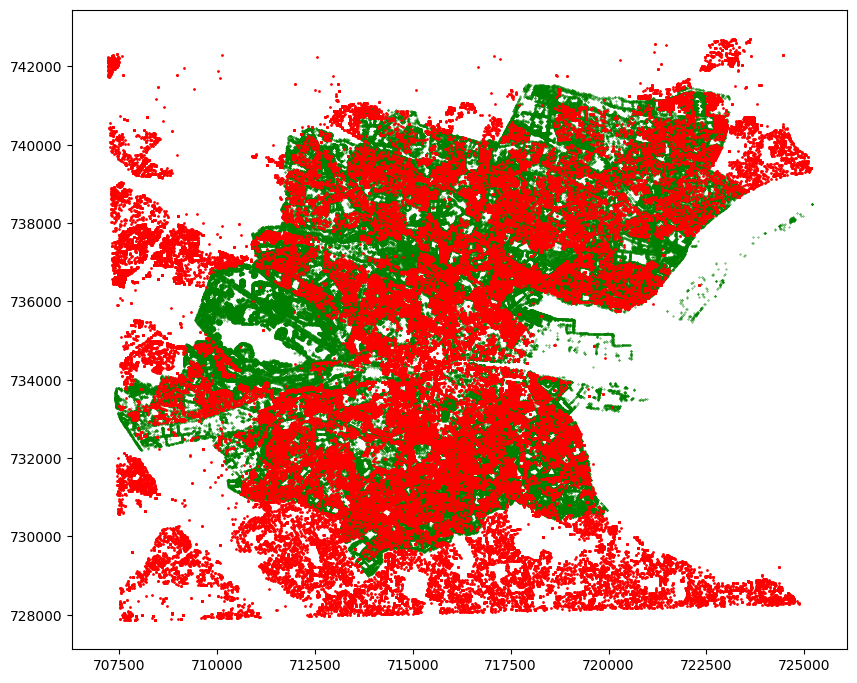

In [56]:
# Look at a 500m+ row
far_row = output[output['dist_to_tree'] > 500].iloc[0]
print(output[['latitude', 'longitude', 'dist_to_tree']])

# Plot a quick check
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
trees_proj.plot(ax=ax, color='green', markersize=0.1)
ppr_proj.plot(ax=ax, color='red', markersize=1)
plt.show()

In [57]:
output

,year,price,dist_to_tree,distance_band,tree_species,tree_vitality,tree_height,latitude,longitude,description
0,2020,588500.0,13.095330,0-50m,sycamore,Good,6.2,53.313280,-6.246720,Second-Hand Dwelling house /Apartment
1,2020,232500.0,24.633645,0-50m,None,Good,0.0,53.311160,-6.273200,Second-Hand Dwelling house /Apartment
2,2020,360000.0,11.209385,0-50m,None,None,3.5,53.365510,-6.285400,Second-Hand Dwelling house /Apartment
4,2020,660000.0,202.438615,200-500m,english oak,Good,11.1,53.372590,-6.342630,New Dwelling house /Apartment
5,2020,624600.0,7.898378,0-50m,london plane,None,9.7,53.334500,-6.247500,Second-Hand Dwelling house /Apartment
...,...,...,...,...,...,...,...,...,...,...
274210,2026,336000.0,15.496442,0-50m,None,Good,3.3,53.325949,-6.266439,Second-Hand Dwelling house /Apartment
274211,2026,547000.0,14.217059,0-50m,None,Good,10.1,53.321588,-6.289371,Second-Hand Dwelling house /Apartment
274212,2026,580000.0,13.927173,0-50m,None,Good,4.1,53.390171,-6.233227,Second-Hand Dwelling house /Apartment
274213,2026,760000.0,61.726617,50-100m,plàtan,Good,0.0,53.352895,-6.274779,Second-Hand Dwelling house /Apartment


In [58]:
output = output[
    (output['latitude'] >= 53.298972) & (output['latitude'] <= 53.410981) &
    (output['longitude'] >= -6.387205) & (output['longitude'] <= -6.118089) &
    (output['dist_to_tree'] <= 501)
].copy()

print(f"After filter: {len(output)}")
print(output['distance_band'].value_counts())

After filter: 80646
distance_band
0-50m       71968
200-500m     3867
50-100m      2793
100-200m     2013
500m+           5
Name: count, dtype: int64


In [59]:
# Project combined to ITM
ppr_proj2 = gpd.GeoDataFrame(
    output,
    geometry=gpd.points_from_xy(output['longitude'], output['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:2157')

# Count trees within different radii for each property
for radius in [50, 100, 200]:
    print(f"Counting trees within {radius}m...")
    buffers = ppr_proj2.copy()
    buffers['geometry'] = buffers.geometry.buffer(radius)
    joined = gpd.sjoin(buffers, trees_proj[['geometry']], how='left', predicate='contains')
    tree_counts = joined.groupby(joined.index).size().reindex(output.index, fill_value=0)
    output[f'trees_within_{radius}m'] = tree_counts.values

print(output[['trees_within_50m', 'trees_within_100m', 'trees_within_200m']].describe())

Counting trees within 50m...
Counting trees within 100m...
Counting trees within 200m...
       trees_within_50m  trees_within_100m  trees_within_200m
count      80646.000000       80646.000000       80646.000000
mean          18.002616          73.817214         296.957741
std           14.405243          50.180197         173.611630
min            1.000000           1.000000           1.000000
25%            7.000000          40.000000         183.000000
50%           16.000000          67.000000         277.000000
75%           25.000000         101.000000         394.000000
max          144.000000         524.000000        1830.000000


In [60]:
print(output['description'].value_counts())

description
Second-Hand Dwelling house /Apartment    73668
New Dwelling house /Apartment             6977
Teach/Árasán Cónaithe Atháimhe               1
Name: count, dtype: int64


In [61]:
# Property type
output['property_type'] = output['description'].apply(
    lambda x: 'New' if 'New' in str(x) else 'Second-Hand'
)

print(output['property_type'].value_counts())

# Drop description now we have property_type
output = output.drop(columns=['description'])

# Export
output.to_csv('data/dublin_trees_prices.csv', index=False)
print(f"Exported {len(output)} rows")
print(output.columns.tolist())

property_type
Second-Hand    73669
New             6977
Name: count, dtype: int64
Exported 80646 rows
['year', 'price', 'dist_to_tree', 'distance_band', 'tree_species', 'tree_vitality', 'tree_height', 'latitude', 'longitude', 'trees_within_50m', 'trees_within_100m', 'trees_within_200m', 'property_type']


In [67]:
bins = [0, 10, 20, 50, 100, 500]
labels = ['0-10m', '10-20m', '20-50m', '50-100m', '100-500m']
output['distance_band'] = pd.cut(output['dist_to_tree'], bins=bins, labels=labels)
print(output['distance_band'].value_counts().sort_index())

distance_band
0-10m       15509
10-20m      37298
20-50m      19161
50-100m      2793
100-500m     5880
Name: count, dtype: int64


/var/folders/dk/ld8crfs52l5bcrh5wv3_hy5r0000gn/T/ipykernel_75764/392332259.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_year = output.groupby(['year', 'distance_band'])['price'].median().reset_index()
/var/folders/dk/ld8crfs52l5bcrh5wv3_hy5r0000gn/T/ipykernel_75764/392332259.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  output.groupby('tree_count_band')['price'].median().plot(kind='bar', ax=axes[1, 1], color='green', edgecolor='black')


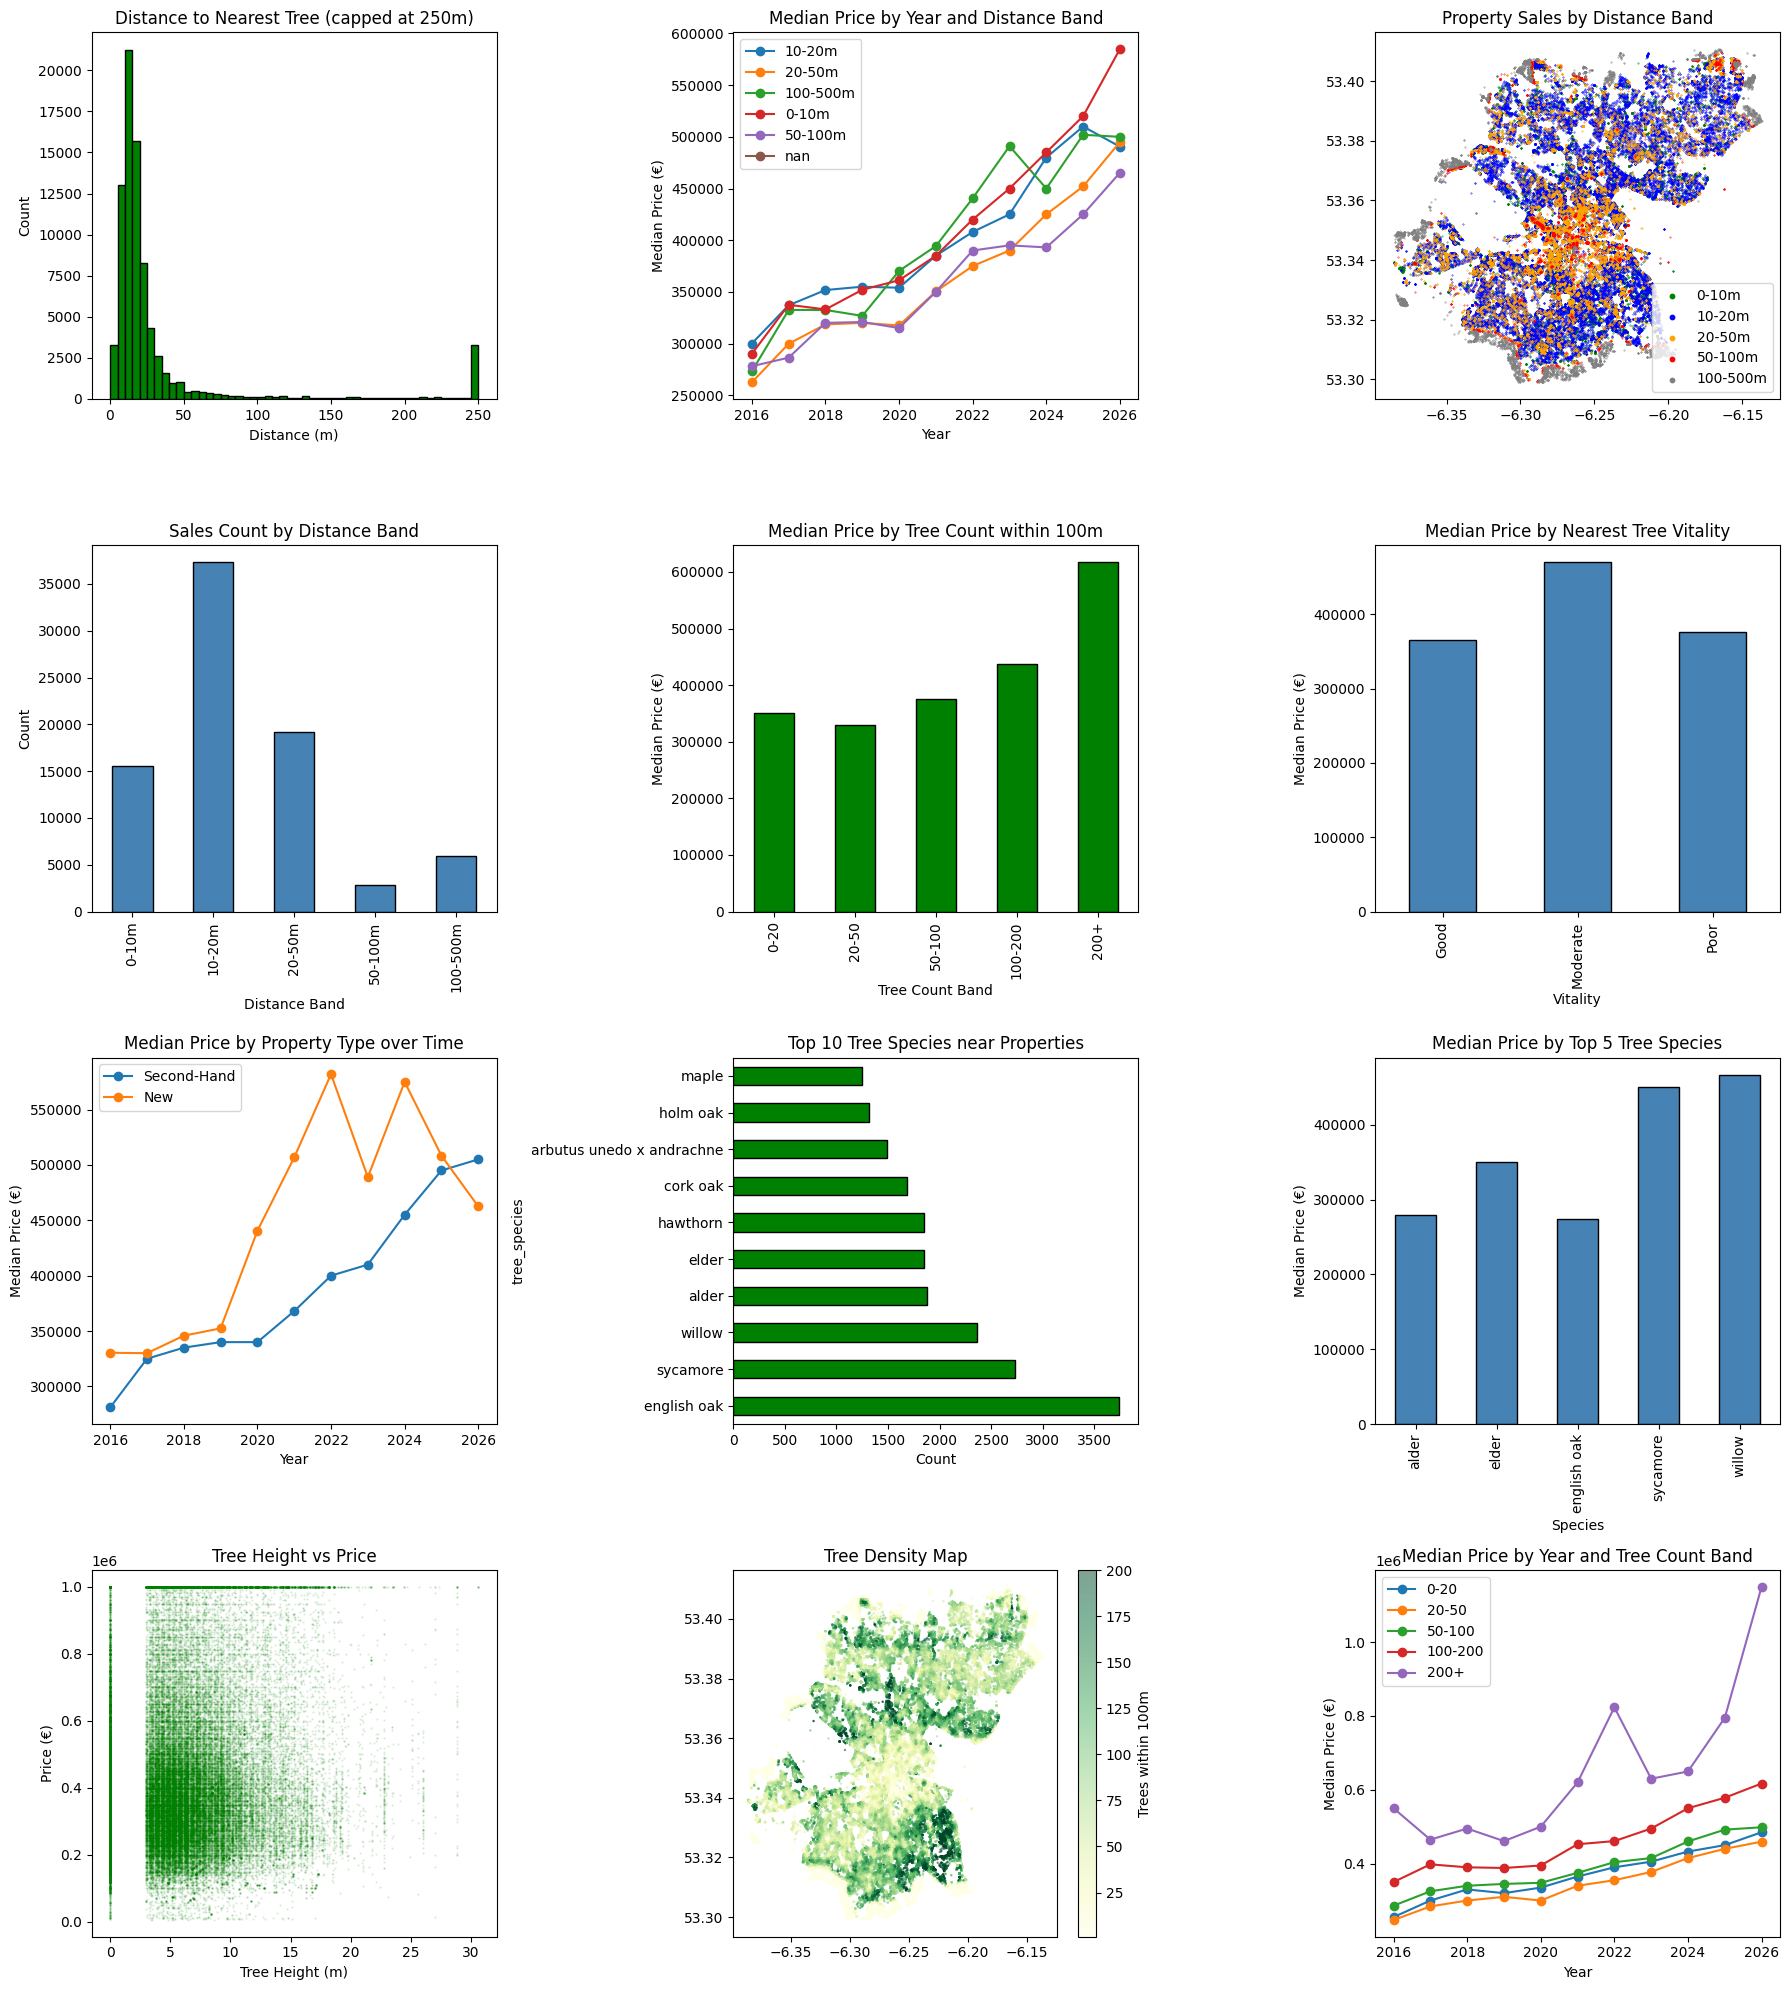

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

# 1. Distribution of distances to nearest tree
axes[0, 0].hist(output['dist_to_tree'].clip(upper=250), bins=50, color='green', edgecolor='black')
axes[0, 0].set_title('Distance to Nearest Tree (capped at 250m)')
axes[0, 0].set_xlabel('Distance (m)')
axes[0, 0].set_ylabel('Count')

# 2. Median price by year split by distance band
price_by_year = output.groupby(['year', 'distance_band'])['price'].median().reset_index()
for band in output['distance_band'].unique():
    data = price_by_year[price_by_year['distance_band'] == band]
    axes[0, 1].plot(data['year'], data['price'], marker='o', label=band)
axes[0, 1].set_title('Median Price by Year and Distance Band')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Median Price (€)')
axes[0, 1].legend()

# 3. Map of property sales coloured by distance band
colors = {'0-10m': 'green', '10-20m': 'blue', '20-50m': 'orange', '50-100m': 'red', '100-500m': 'grey'}
for band, color in colors.items():
    subset = output[output['distance_band'] == band]
    axes[0, 2].scatter(subset['longitude'], subset['latitude'], c=color, s=0.1, label=band)
axes[0, 2].set_title('Property Sales by Distance Band')
axes[0, 2].legend(markerscale=10)

# 4. Distance band counts
output['distance_band'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_title('Sales Count by Distance Band')
axes[1, 0].set_xlabel('Distance Band')
axes[1, 0].set_ylabel('Count')

# 5. Median price by trees within 100m binned
output['tree_count_band'] = pd.cut(output['trees_within_100m'], bins=[0, 20, 50, 100, 200, 600], labels=['0-20', '20-50', '50-100', '100-200', '200+'])
output.groupby('tree_count_band')['price'].median().plot(kind='bar', ax=axes[1, 1], color='green', edgecolor='black')
axes[1, 1].set_title('Median Price by Tree Count within 100m')
axes[1, 1].set_xlabel('Tree Count Band')
axes[1, 1].set_ylabel('Median Price (€)')

# 6. Median price by tree vitality
output.groupby('tree_vitality')['price'].median().plot(kind='bar', ax=axes[1, 2], color='steelblue', edgecolor='black')
axes[1, 2].set_title('Median Price by Nearest Tree Vitality')
axes[1, 2].set_xlabel('Vitality')
axes[1, 2].set_ylabel('Median Price (€)')

# 7. Median price by property type over time
for ptype in ['Second-Hand', 'New']:
    data = output[output['property_type'] == ptype].groupby('year')['price'].median()
    axes[2, 0].plot(data.index, data.values, marker='o', label=ptype)
axes[2, 0].set_title('Median Price by Property Type over Time')
axes[2, 0].set_xlabel('Year')
axes[2, 0].set_ylabel('Median Price (€)')
axes[2, 0].legend()

# 8. Top 10 tree species by count
output['tree_species'].value_counts().head(10).plot(kind='barh', ax=axes[2, 1], color='green', edgecolor='black')
axes[2, 1].set_title('Top 10 Tree Species near Properties')
axes[2, 1].set_xlabel('Count')

# 9. Median price by top 5 tree species
top5_species = output['tree_species'].value_counts().head(5).index
species_data = output[output['tree_species'].isin(top5_species)]
species_data.groupby('tree_species')['price'].median().plot(kind='bar', ax=axes[2, 2], color='steelblue', edgecolor='black')
axes[2, 2].set_title('Median Price by Top 5 Tree Species')
axes[2, 2].set_xlabel('Species')
axes[2, 2].set_ylabel('Median Price (€)')

# 10. Tree height vs price scatter
axes[3, 0].scatter(output['tree_height'], output['price'].clip(upper=1000000), alpha=0.1, s=0.5, color='green')
axes[3, 0].set_title('Tree Height vs Price')
axes[3, 0].set_xlabel('Tree Height (m)')
axes[3, 0].set_ylabel('Price (€)')

# 11. Map coloured by tree count within 100m
scatter = axes[3, 1].scatter(
    output['longitude'], output['latitude'],
    c=output['trees_within_100m'].clip(upper=200),
    cmap='YlGn', s=0.5, alpha=0.5
)
plt.colorbar(scatter, ax=axes[3, 1], label='Trees within 100m')
axes[3, 1].set_title('Tree Density Map')

# 12. Median price by year and property type split by tree count band
for tband in ['0-20', '20-50', '50-100', '100-200', '200+']:
    data = output[output['tree_count_band'] == tband].groupby('year')['price'].median()
    axes[3, 2].plot(data.index, data.values, marker='o', label=tband)
axes[3, 2].set_title('Median Price by Year and Tree Count Band')
axes[3, 2].set_xlabel('Year')
axes[3, 2].set_ylabel('Median Price (€)')
axes[3, 2].legend()

plt.tight_layout()
plt.savefig('data/exploratory_plots.png', dpi=150)
plt.show()

In [73]:
# Final check before export
print(f"Total rows: {len(output)}")
print(f"Columns: {output.columns.tolist()}")
print(f"Year range: {output['year'].min()} to {output['year'].max()}")
print(f"Price range: {output['price'].min()} to {output['price'].max()}")
print(f"Null values:\n{output.isnull().sum()}")
print(output.head(3).to_string())

Total rows: 80631
Columns: ['year', 'price', 'dist_to_tree', 'distance_band', 'tree_species', 'tree_vitality', 'tree_height', 'latitude', 'longitude', 'trees_within_50m', 'trees_within_100m', 'trees_within_200m', 'property_type', 'tree_count_band']
Year range: 2016 to 2026
Price range: 5250.0 to 59789058.0
Null values:
year                     0
price                    0
dist_to_tree             0
distance_band            5
tree_species         41169
tree_vitality        13667
tree_height              0
latitude                 0
longitude                0
trees_within_50m         0
trees_within_100m        0
trees_within_200m        0
property_type            0
tree_count_band          0
dtype: int64
   year     price  dist_to_tree distance_band tree_species tree_vitality  tree_height  latitude  longitude  trees_within_50m  trees_within_100m  trees_within_200m property_type tree_count_band
0  2020  588500.0     13.095330        10-20m     sycamore          Good          6.2  53.31328

In [74]:
output = output[output['price'] <= 60000000].copy()
print(f"Rows after price filter: {len(output)}")
print(f"Max price: {output['price'].max()}")

Rows after price filter: 80631
Max price: 59789058.0


In [75]:
# Export
output.to_csv('data/final_dublin_trees_prices.csv', index=False)
print(f"\nSaved to data/final_dublin_trees_prices.csv")


Saved to data/final_dublin_trees_prices.csv


# Vegalite

In [80]:
import altair as alt
import pandas as pd

vega_data = pd.read_csv('data/final_dublin_trees_prices.csv', low_memory=False)
print(f"Loaded {len(vega_data)} rows")
print(vega_data.columns.tolist())

Loaded 80631 rows
['year', 'price', 'dist_to_tree', 'distance_band', 'tree_species', 'tree_vitality', 'tree_height', 'latitude', 'longitude', 'trees_within_50m', 'trees_within_100m', 'trees_within_200m', 'property_type', 'tree_count_band']


In [81]:
vega_data

,year,price,dist_to_tree,distance_band,tree_species,tree_vitality,tree_height,latitude,longitude,trees_within_50m,trees_within_100m,trees_within_200m,property_type,tree_count_band
0,2020,588500.0,13.095330,10-20m,sycamore,Good,6.2,53.313280,-6.246720,25,127,374,Second-Hand,100-200
1,2020,232500.0,24.633645,20-50m,NaN,Good,0.0,53.311160,-6.273200,15,59,387,Second-Hand,50-100
2,2020,360000.0,11.209385,10-20m,NaN,NaN,3.5,53.365510,-6.285400,7,63,302,Second-Hand,50-100
3,2020,660000.0,202.438615,100-500m,english oak,Good,11.1,53.372590,-6.342630,1,1,1,New,0-20
4,2020,624600.0,7.898378,0-10m,london plane,NaN,9.7,53.334500,-6.247500,10,91,339,Second-Hand,50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80626,2026,336000.0,15.496442,10-20m,NaN,Good,3.3,53.325949,-6.266439,11,50,220,Second-Hand,20-50
80627,2026,547000.0,14.217059,10-20m,NaN,Good,10.1,53.321588,-6.289371,27,108,328,Second-Hand,100-200
80628,2026,580000.0,13.927173,10-20m,NaN,Good,4.1,53.390171,-6.233227,30,123,362,Second-Hand,100-200
80629,2026,760000.0,61.726617,50-100m,plàtan,Good,0.0,53.352895,-6.274779,2,34,354,Second-Hand,20-50


# Converting Dublin geojson

In [85]:
import geopandas as gpd

# Read the ITM GeoJSON
dcc = gpd.read_file('vega/dublin.geojson')
print(dcc.crs)

# Convert to WGS84
dcc_wgs84 = dcc.to_crs('EPSG:4326')

# Save as new GeoJSON
dcc_wgs84.to_file('vega/dublin_wgs84.geojson', driver='GeoJSON')
print("Saved")

EPSG:2157
Saved


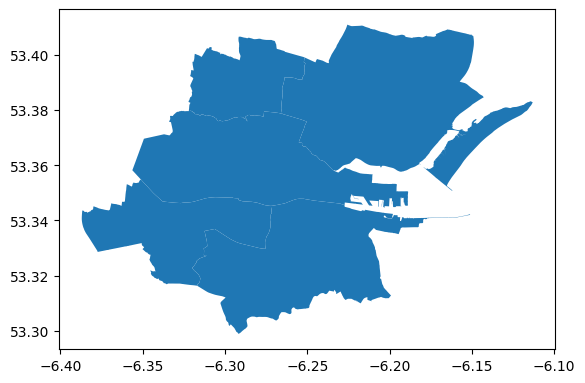

In [88]:
dcc = gpd.read_file('vega/dublin_wgs84.geojson')
dcc.plot()
plt.show()

In [89]:
print(dcc.shape)
print(dcc['Name'].values)
print(dcc.geometry.bounds)

(5, 2)
['NORTH WEST' 'NORTH CENTRAL' 'SOUTH EAST' 'SOUTH CENTRAL' 'CENTRAL']
       minx       miny      maxx       maxy
0 -6.322236  53.375949 -6.251212  53.406646
1 -6.265841  53.350741 -6.113095  53.410992
2 -6.319949  53.298882 -6.151106  53.347867
3 -6.387058  53.316319 -6.271628  53.354867
4 -6.356337  53.344683 -6.188750  53.379803


In [90]:
import geopandas as gpd
from shapely.ops import transform

dcc = gpd.read_file('vega/dublin_wgs84.geojson')

# Strip Z coordinates
dcc['geometry'] = dcc['geometry'].apply(
    lambda geom: transform(lambda x, y, z=None: (x, y), geom)
)

dcc.to_file('vega/dublin_wgs84.geojson', driver='GeoJSON')
print("Saved without Z coordinates")

Saved without Z coordinates


In [93]:
# Load DCC boundary
dcc = gpd.read_file('vega/dublin_wgs84.geojson')
dcc_union = dcc.dissolve()

# Convert properties to GeoDataFrame
ppr_geo = gpd.GeoDataFrame(
    output,
    geometry=gpd.points_from_xy(output['longitude'], output['latitude']),
    crs='EPSG:4326'
)

# Keep only points within DCC boundary
ppr_within_dcc = gpd.sjoin(ppr_geo, dcc_union[['geometry']], how='inner', predicate='within')

print(f"Before: {len(output)}")
print(f"After: {len(ppr_within_dcc)}")

# Export
ppr_within_dcc.drop(columns=['geometry', 'index_right']).to_csv('vega/final_dublin_trees_prices.csv', index=False)
print("Saved")

Before: 80631
After: 73547
Saved


In [117]:
df = pd.read_csv("vega/final_dublin_trees_prices.csv")

print("Price percentiles:")
print(df["price"].quantile([0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

Price percentiles:
0.05     165000.0
0.25     272000.0
0.50     372000.0
0.75     531987.5
0.90     850000.0
0.95    1235000.0
0.99    2680000.0
Name: price, dtype: float64
